# Song Classification using k-Nearest Neighbors (kNN)

In this notebook, we will use the k-Nearest Neighbors (kNN) algorithm to classify songs based on various features. Our approach includes the following steps:

1. **Data Preprocessing**: 
   - We load and prepare the dataset, which contains information about songs (e.g., tempo, duration, and loudness).
   - **Feature Engineering**: 
     - We induce new features as combinations of existing ones to capture more meaningful patterns:
       - **Tempo-Duration Ratio**: We create a new feature that combines tempo and duration to see if tempo influences the length of the song.
       - **Log-Transformed Duration**: We apply a log transformation to the duration to handle skewness and outliers.
     
2. **Scaling**:
   - To ensure that all features are on a similar scale, we apply different scaling methods (e.g., StandardScaler, MinMaxScaler, and RobustScaler) before applying the kNN classifier.

3. **Modeling**:
   - We use the **kNN algorithm** for classification. Grid search and cross-validation are employed to tune hyperparameters and evaluate the model's performance.

4. **Hyperparameter Tuning**:
   - Grid Search is utilized to find the best parameters for the kNN algorithm, such as the optimal number of neighbors, distance metrics, and weights.

5. **Cross-Validation**:
   - Cross-validation is used to ensure the model's robustness and prevent overfitting during hyperparameter tuning.

6. **Evaluation and Visualization**:
   - We evaluate the model using test accuracy and visualize the best performing scaling method and model.

In [3]:
%%time
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

data = pd.read_csv("songs.csv")

# Drop irrelevant columns
irrelevant_columns = ["Artist Name", "Track Name"]
data = data.drop(columns=irrelevant_columns)

# Fill missing values in numerical columns with the mean of the column
data = data.fillna(data.mean())

# Combine tempo and duration
data['tempo_duration_ratio'] = data['tempo'] / data['duration_in min/ms'] # New feature no. 1

# Apply log transformation to duration
data['log_duration'] = np.log1p(data['duration_in min/ms']) # New feature no. 2

# Define features (X) and target (y)
X = data.drop(columns=["Class"])
y = data["Class"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling Options
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

best_accuracy = 0
best_scaler_name = ""
best_knn_model = None

for scaler_name, scaler in scalers.items():
    print(f"\nUsing scaler: {scaler_name}")
    
    # Scale the features
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize the kNN model
    knn = KNeighborsClassifier()

    # Perform Grid Search with Cross-Validation to find the best hyperparameters
    param_grid = {
        'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2, 3]  # Adding power parameter for Minkowski distance
    }
    grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train_scaled, y_train)

    # Evaluate the best model on the test set
    best_knn = grid_search.best_estimator_
    y_pred = best_knn.predict(X_test_scaled)
    test_accuracy = accuracy_score(y_test, y_pred)

    print("Best Parameters from Grid Search:", grid_search.best_params_)
    print("Cross-Validation Accuracy:", grid_search.best_score_)
    print("Test Accuracy:", test_accuracy)

    # Keep track of the best scaler and model
    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        best_scaler_name = scaler_name
        best_knn_model = best_knn

print("\nBest Scaler:", best_scaler_name)
print("Best Test Accuracy:", best_accuracy)
print("Best kNN Model:", best_knn_model)


Using scaler: StandardScaler
Best Parameters from Grid Search: {'metric': 'manhattan', 'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}
Cross-Validation Accuracy: 0.4902750038593647
Test Accuracy: 0.4872222222222222

Using scaler: MinMaxScaler
Best Parameters from Grid Search: {'metric': 'manhattan', 'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}
Cross-Validation Accuracy: 0.4806195004052333
Test Accuracy: 0.48694444444444446

Using scaler: RobustScaler
Best Parameters from Grid Search: {'metric': 'manhattan', 'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}
Cross-Validation Accuracy: 0.4237990139323067
Test Accuracy: 0.4330555555555556

Best Scaler: StandardScaler
Best Test Accuracy: 0.4872222222222222
Best kNN Model: KNeighborsClassifier(metric='manhattan', n_neighbors=15, p=1)
CPU times: total: 1h 53min 33s
Wall time: 29min 59s


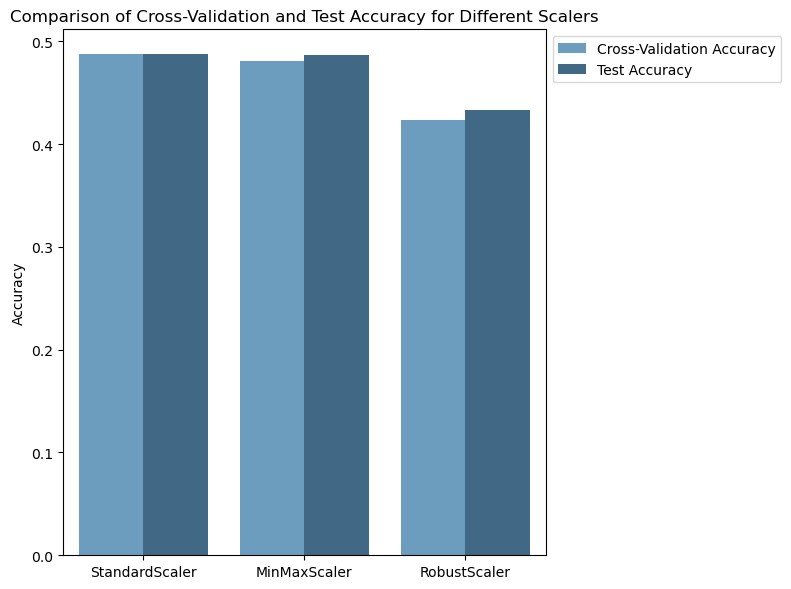

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Results for each scaler
scalers = ['StandardScaler', 'MinMaxScaler', 'RobustScaler']
cross_val_accuracies = [0.4872222222222222, 0.4806195004052333, 0.4237990139323067]
test_accuracies = [0.4872222222222222, 0.48694444444444446, 0.4330555555555556]

# Prepare data for visualization
results = {
    'Scaler': scalers,
    'Cross-Validation Accuracy': cross_val_accuracies,
    'Test Accuracy': test_accuracies
}

# Create a DataFrame
results_df = pd.DataFrame(results)

# Visualization: Bar plot for Cross-Validation and Test Accuracy for each scaler
plt.figure(figsize=(8, 6))
sns.barplot(x='Scaler', y='value', hue='variable', data=pd.melt(results_df, id_vars=['Scaler'], 
                                                               value_vars=['Cross-Validation Accuracy', 'Test Accuracy'],
                                                               var_name='variable', value_name='value'),
            palette="Blues_d")

plt.xlabel('')
plt.legend(title='', loc='upper left', bbox_to_anchor=(1, 1))
plt.title('Comparison of Cross-Validation and Test Accuracy for Different Scalers')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

In [19]:
data.head(10)

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class,tempo_duration_ratio,log_duration
0,60.0,0.854,0.564,1.0,-4.964,1,0.0485,0.017100,0.177562,0.0849,0.8990,134.071,234596.000000,4,5,0.000571,12.365624
1,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.000000,4,10,0.000463,12.436128
2,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.000000,4,6,0.001347,11.605213
3,66.0,0.853,0.597,10.0,-6.528,0,0.0555,0.021200,0.177562,0.1220,0.5690,107.033,173968.000000,4,5,0.000615,12.066632
4,53.0,0.167,0.975,2.0,-4.279,1,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.000000,4,10,0.000866,12.345665
5,53.0,0.235,0.977,6.0,0.878,1,0.1070,0.003530,0.006040,0.1720,0.2410,152.952,208133.000000,4,6,0.000735,12.245937
6,48.0,0.674,0.658,5.0,-9.647,0,0.1040,0.404000,0.000001,0.0981,0.6770,143.292,329387.000000,4,2,0.000435,12.704992
7,55.0,0.657,0.415,5.0,-9.915,1,0.0250,0.175000,0.000006,0.1320,0.3470,96.030,3.105783,4,4,30.919736,1.412397
8,29.0,0.431,0.776,10.0,-5.403,1,0.0527,0.000022,0.001300,0.1790,0.3180,120.857,237867.000000,4,8,0.000508,12.379471
9,14.0,0.716,0.885,1.0,-4.348,0,0.0333,0.061400,0.177562,0.2530,0.8330,128.043,164093.000000,4,9,0.000780,12.008195


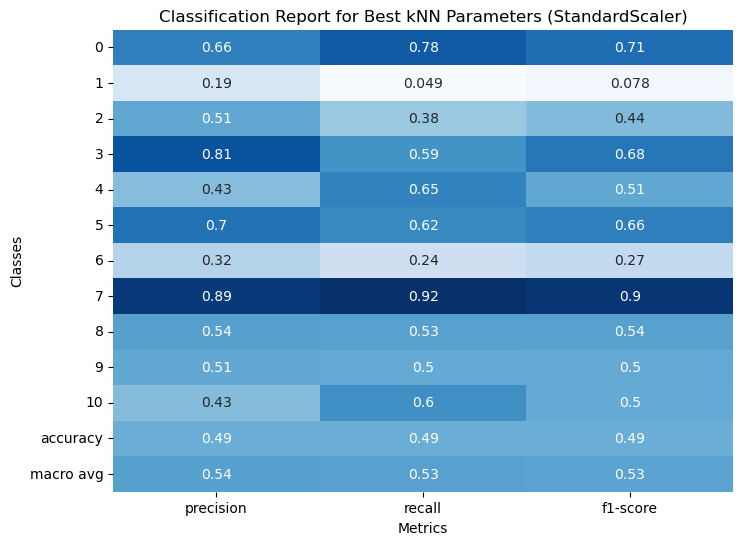

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Reviewing and re-using the ideal parameters
X = data.drop(columns=["Class"])
y = data["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn = KNeighborsClassifier(metric='manhattan', n_neighbors=15, p=1, weights='uniform')

# Fit the model to the training data
knn.fit(X_train_scaled, y_train)

# Generate predictions on the test set
y_pred = knn.predict(X_test_scaled)

# Get the classification report
report = classification_report(y_test, y_pred, output_dict=True)

# Convert the classification report to a DataFrame
report_df = pd.DataFrame(report).transpose()

# Plot the heatmap for the classification report
plt.figure(figsize=(8, 6))
sns.heatmap(report_df.iloc[:-1, :-1].astype(float), annot=True, cmap='Blues', cbar=False,
            xticklabels=report_df.columns[:-1], yticklabels=report_df.index[:-1])
plt.title('Classification Report for Best kNN Parameters (StandardScaler)')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.show()

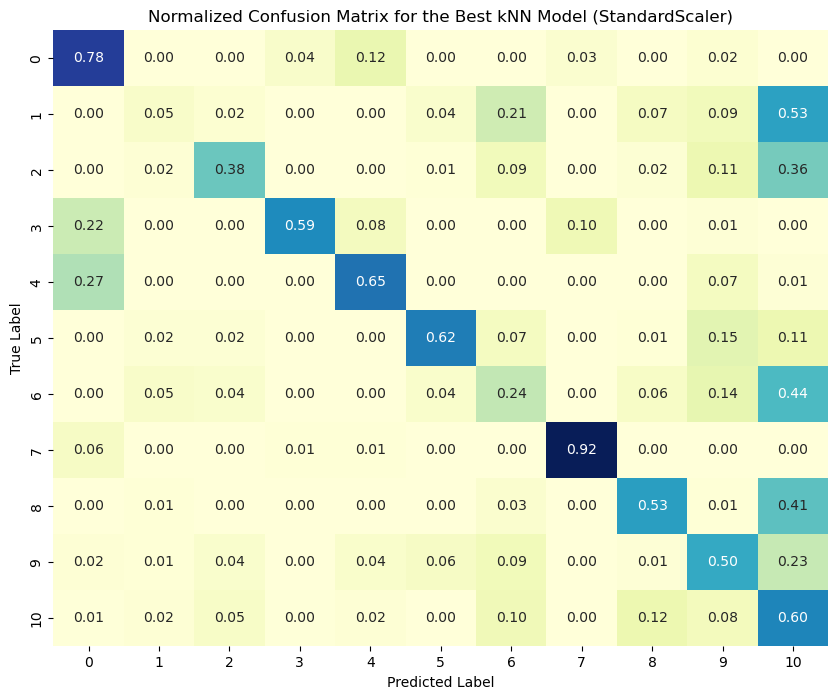

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Reviewing and re-using the ideal parameters
X = data.drop(columns=["Class"])
y = data["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn = KNeighborsClassifier(metric='manhattan', n_neighbors=15, p=1, weights='uniform')

# Fit the model and make predictions
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize the confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot the confusion matrix with normalized values
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlGnBu', cbar=False, xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.title('Normalized Confusion Matrix for the Best kNN Model (StandardScaler)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()